## Libreria SDV

Autor: Oscar Iván Escamilla Guevara

Fecha: 04 de junio de 2026

In [1]:
#Importamos librerias
import pandas as pd
import numpy as np
import random

In [2]:
import sdv #Generar datos sinteticos
import sdmetrics #Evaluar la cantidad de los datos guardados

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [3]:
from sdmetrics.reports.single_table import QualityReport

In [4]:
import sdv
print("SDV", sdv.__version__)

SDV 1.37.0


In [5]:
#Creamos un Dataset (original) que servira como fuente para crear los datos sinteticos
dfClientes = pd.DataFrame({
    "cliente_id" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "edad" : [23, 33, 43, 28,  53, 56, 43, 56, 65, 40],
    "ingreso_mensual" : [25000, 15000, 20000, 10000, 5000, 17000, 30000, 12000, 35000, 7500],
    "ciudad" : ["Córdoba", "Amatlan", "Yanga", "Cuitlahuac", "Orizaba", "Fortín", "Paso del macho", "Cuitlahuac", "Córdoba", "Orizaba"]
})

In [6]:
#Definir los metadatos
metadata = SingleTableMetadata()

In [7]:
metadata.detect_from_dataframe(
    data=dfClientes
)

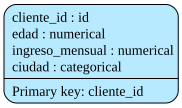

In [8]:
# Instalar el completo graphviz (URL/winget)
metadata.visualize()

In [9]:
metadata.to_dict()

{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'primary_key': 'cliente_id'}

In [12]:
#Guardamos el metadata en un archivo JSON
metadata.save_to_json(
    "dfClientes_metadata.json", mode="overwrite"
)

In [13]:
# Ebtrebanis ek nideki oara geberar kis datis sintéticos
synthesizer = GaussianCopulaSynthesizer(
    metadata
)

In [14]:
# Entrenamiento
synthesizer.fit(
    dfClientes
)

In [15]:
#Generamos los datos sintéticos
clientes_sinteticos = synthesizer.sample (
    num_rows=100
)

In [16]:
clientes_sinteticos.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,16169768,60,27593,Amatlan
1,4918803,31,28370,Cuitlahuac
2,1900081,45,26043,Orizaba
3,531516,33,31913,Fortín
4,10211768,44,32927,Yanga


In [17]:
clientes_sinteticos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       100 non-null    int64 
 1   edad             100 non-null    int64 
 2   ingreso_mensual  100 non-null    int64 
 3   ciudad           100 non-null    object
dtypes: int64(3), object(1)
memory usage: 3.3+ KB


In [18]:
clientes_sinteticos.describe(include="all")

,cliente_id,edad,ingreso_mensual,ciudad
count,1.000000e+02,100.000000,100.000000,100
unique,NaN,NaN,NaN,7
top,NaN,NaN,NaN,Cuitlahuac
freq,NaN,NaN,NaN,21
mean,8.532170e+06,43.540000,21236.880000,NaN
std,4.687773e+06,12.184126,9112.353544,NaN
min,4.660500e+04,28.000000,5862.000000,NaN
25%,5.008268e+06,32.000000,12394.750000,NaN
50%,8.656048e+06,41.000000,21611.000000,NaN
75%,1.256688e+07,55.000000,29789.750000,NaN


In [19]:
#Dataframe contaminado
dfClientesGIGO = clientes_sinteticos.copy()

In [20]:
#Colocar edades imposibles
indices = random.sample(list(dfClientesGIGO.index), 5)

In [21]:
dfClientesGIGO.loc[indices, "edad"] = -5

In [22]:
#Introducimos valores duplicados
duplicados = dfClientesGIGO.sample(10, random_state=42)

In [23]:
dfClientesGIGO = pd.concat([dfClientesGIGO, duplicados], ignore_index=True)

In [24]:
#Verificamos valores nulos
dfClientesGIGO.duplicated().sum()

np.int64(10)

In [25]:
dfClientesGIGO.describe(include="all")

,cliente_id,edad,ingreso_mensual,ciudad
count,1.100000e+02,110.000000,110.000000,110
unique,NaN,NaN,NaN,7
top,NaN,NaN,NaN,Orizaba
freq,NaN,NaN,NaN,24
mean,8.614045e+06,40.572727,20652.327273,NaN
std,4.775996e+06,16.265830,9141.912369,NaN
min,4.660500e+04,-5.000000,5862.000000,NaN
25%,4.948624e+06,31.000000,11956.000000,NaN
50%,8.956428e+06,38.000000,20023.000000,NaN
75%,1.274153e+07,55.000000,29685.000000,NaN


In [26]:
#Generamos el reporte
reporte = QualityReport()

In [27]:
reporte.generate (
    real_data = dfClientes,
    synthetic_data = clientes_sinteticos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 425.84it/s]|
Column Shapes Score: 81.33%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 124.20it/s]|
Column Pair Trends Score: 14.5%

Overall Score (Average): 47.92%

